Task 2: Credit Risk Prediction
Objective:
Predict whether a loan applicant is likely to default on a loan.
Dataset:
Loan Prediction Dataset (available on Kaggle)
Instructions:
● Handle missing data appropriately.
● Visualize key features such as loan amount, education, and income.
● Train a classification model like Logistic Regression or Decision Tree.
● Evaluate the model using accuracy and a confusion matrix.

Skills:
● Data cleaning and handling missing values
● Exploratory Data Analysis (EDA)
● Binary classification using machine learning
● Model evaluation using confusion matrix and accuracy

In [269]:
# importing libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report

In [270]:
# Loading Data Set 

In [271]:
data = pd.read_csv('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Data-Set/credit_risk_dataset.csv.zip')

In [272]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [273]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [274]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [275]:
data.person_emp_length.unique()

array([123.,   5.,   1.,   4.,   8.,   2.,   6.,   7.,   0.,   9.,   3.,
        10.,  nan,  11.,  18.,  12.,  17.,  14.,  16.,  13.,  19.,  15.,
        20.,  22.,  21.,  24.,  23.,  26.,  25.,  27.,  28.,  31.,  41.,
        34.,  29.,  38.,  30.])

In [276]:
data['age_group'] = data.person_age.apply(lambda x : 'junior' if 20 < x <= 30 else 'Young' if 30 < x <= 40 else 'Adult' if 40 < x <= 50 else 'Senior'  )

In [277]:
emp_length_age_group = data.groupby('age_group')['person_emp_length'].mean()

In [278]:
data['person_emp_length'] = data.apply(lambda x : emp_length_age_group[x['age_group']] if pd.isna(x['person_emp_length']) else x['person_emp_length'] , axis=1)

In [279]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
age_group                        0
dtype: int64

In [280]:
loan_int_by_cause = data.groupby('loan_intent')['loan_int_rate'].mean()

In [281]:
data['loan_int_rate'] = data.apply(lambda x : loan_int_by_cause[x['loan_intent']] if pd.isna(x['loan_int_rate']) else x['loan_int_rate'] 
                                   ,axis=1)

In [282]:
data.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
age_group                     0
dtype: int64

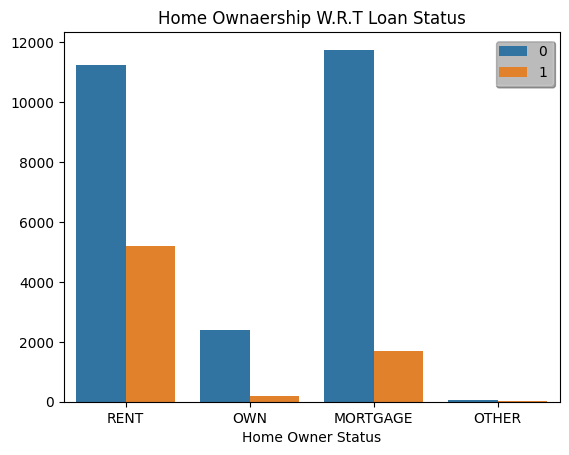

In [283]:
sns.countplot(data=data,x='person_home_ownership',hue='loan_status')
plt.title('Home Ownaership W.R.T Loan Status')
plt.xlabel('Home Owner Status')
plt.ylabel('')
plt.legend(
    fancybox=True,
    framealpha=0.25,
    edgecolor="white",
    shadow=True
)
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/Home_Ownership_W.R.TLoan.png', dpi=300, bbox_inches='tight')
plt.show()

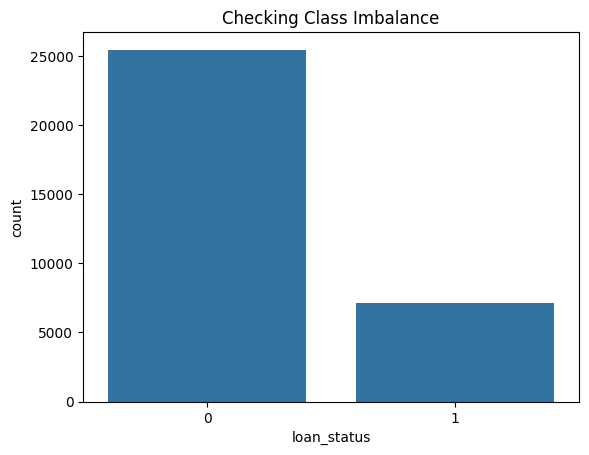

In [284]:
sns.countplot(data=data,x='loan_status')
plt.title('Checking Class Imbalance')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images',dpi=300,bbox_inches='tight')
plt.show()

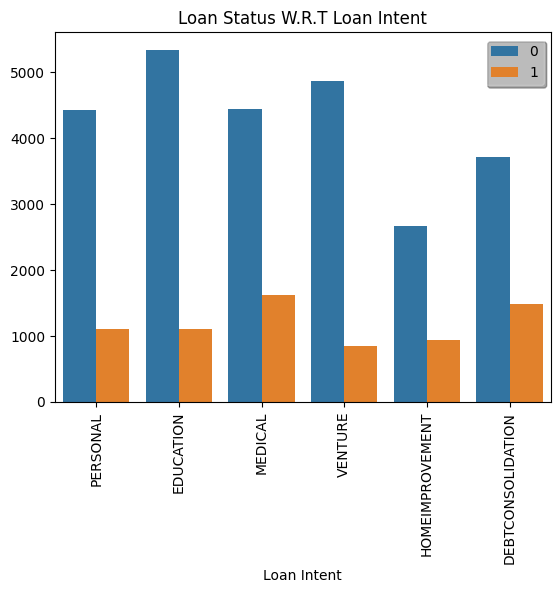

In [285]:
sns.countplot(data=data,x='loan_intent',hue='loan_status')
plt.title('Loan Status W.R.T Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('')
plt.legend(
    fancybox=True,
    framealpha=0.25,
    edgecolor="white",
    shadow=True
)
plt.xticks(rotation=90)
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/Loan_StatusW.R.TIntent.png',dpi=300,bbox_inches='tight')
plt.show()

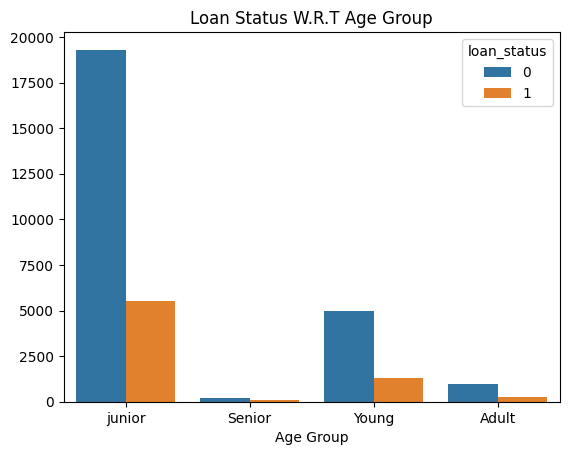

In [286]:
sns.countplot(data=data,x='age_group',hue='loan_status')
plt.title('Loan Status W.R.T Age Group')
plt.xlabel('Age Group')
plt.ylabel('')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/Loan StatusW.R.TAge.png',dpi=300,bbox_inches='tight')
plt.show()

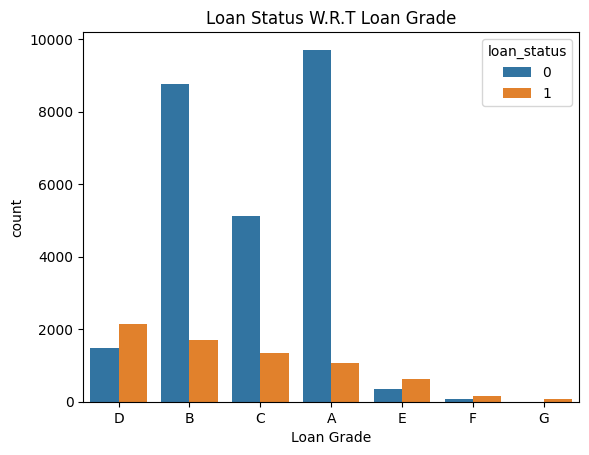

In [287]:
sns.countplot(data=data,x='loan_grade',hue='loan_status')
plt.title('Loan Status W.R.T Loan Grade')
plt.xlabel('Loan Grade')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/Loan_StatusW.R.TLoan_Grade.png',dpi=300,bbox_inches='tight')
plt.show()

In [288]:
# Encoding 

In [289]:
home_status_encoder = OneHotEncoder(sparse_output=False) # Give A Matrix
data_ = home_status_encoder.fit_transform(data[['person_home_ownership']])
data__ = pd.DataFrame(data_,columns=home_status_encoder.get_feature_names_out())
data = pd.concat([data,data__],axis=1)
data.drop('person_home_ownership',inplace=True,axis=1)

In [290]:
data.cb_person_default_on_file = data.cb_person_default_on_file.map({'Y':1,'N':0})

In [291]:
loan_inent_encoder = OneHotEncoder(sparse_output=False)
data_ = loan_inent_encoder.fit_transform(data[['loan_intent']])
data__ = pd.DataFrame(data_,columns=loan_inent_encoder.get_feature_names_out())
data = pd.concat([data,data__],axis=1)
data.drop('loan_intent',axis=1,inplace=True)

In [292]:
data.loan_grade = data.loan_grade.map({'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6})

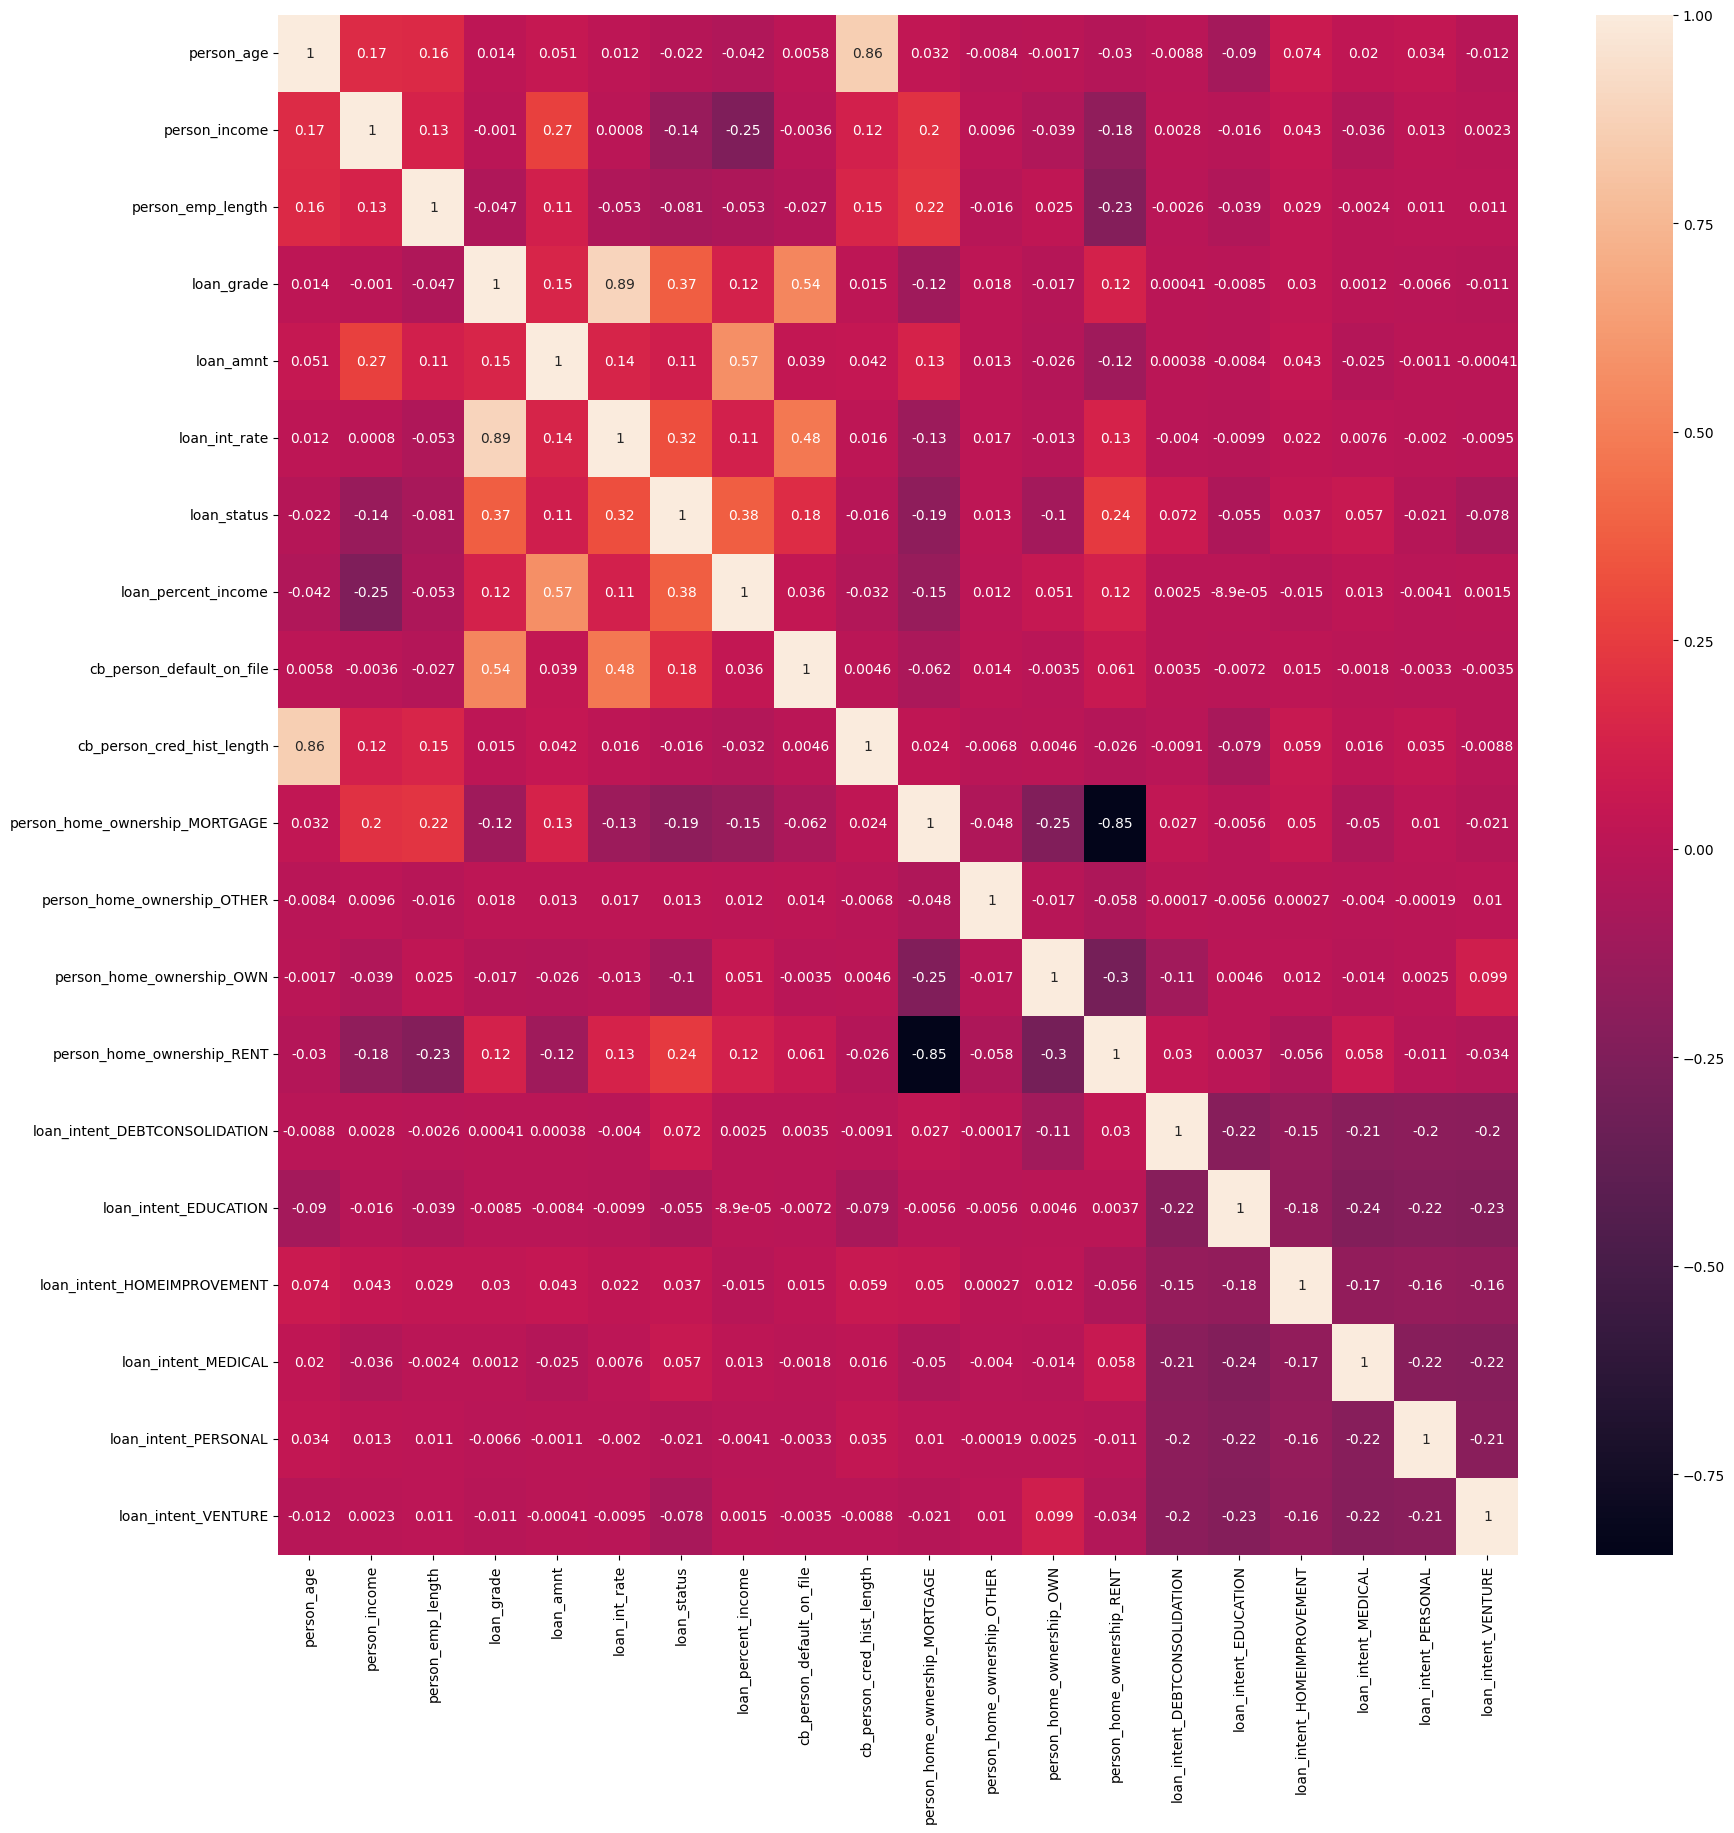

In [293]:
plt.figure(figsize=(20,20))
sns.heatmap(data.drop('age_group',axis=1).corr(),annot=True)

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/HeatMap.png',dpi=300,bbox_inches='tight')
plt.show()

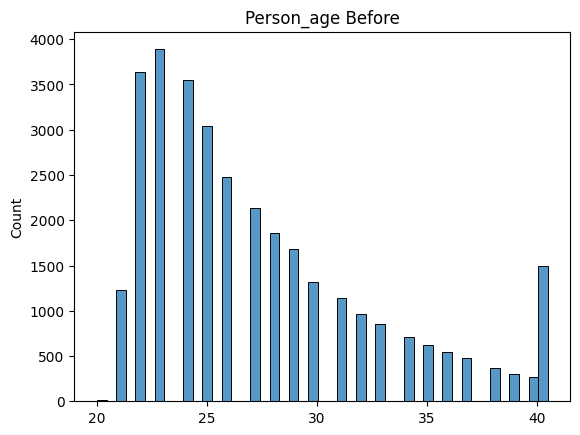

In [325]:
sns.histplot(data=data,x='person_age')
plt.title('Person_age Before')
plt.xlabel('')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_age_before.png',dpi=300,bbox_inches='tight')

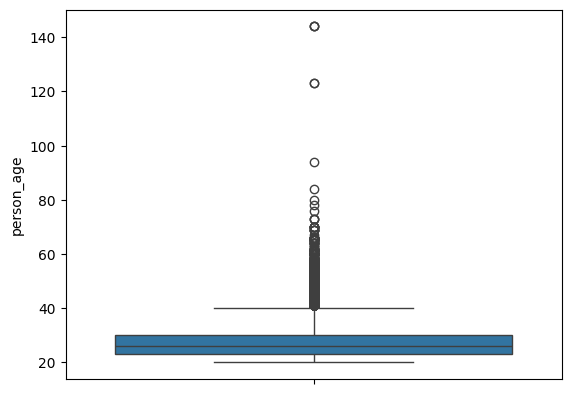

In [295]:
sns.boxplot(data=data,y='person_age')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_age_hist_bef.png',dpi=300,bbox_inches='tight')

In [296]:
Q1 = data['person_age'].quantile(0.25)
Q3 = data['person_age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data['person_age'] = data['person_age'].clip(lower, upper)

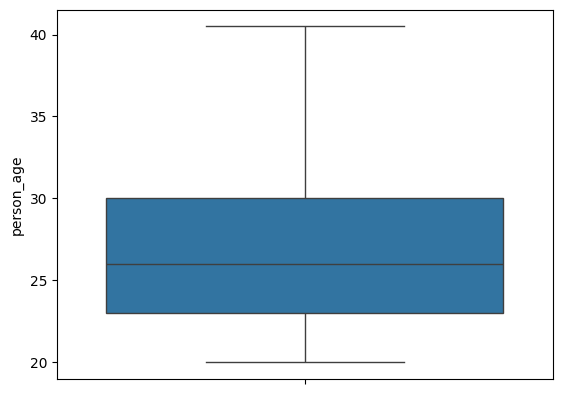

In [297]:
sns.boxplot(data=data,y='person_age')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_age_after.png',dpi=300,bbox_inches='tight')

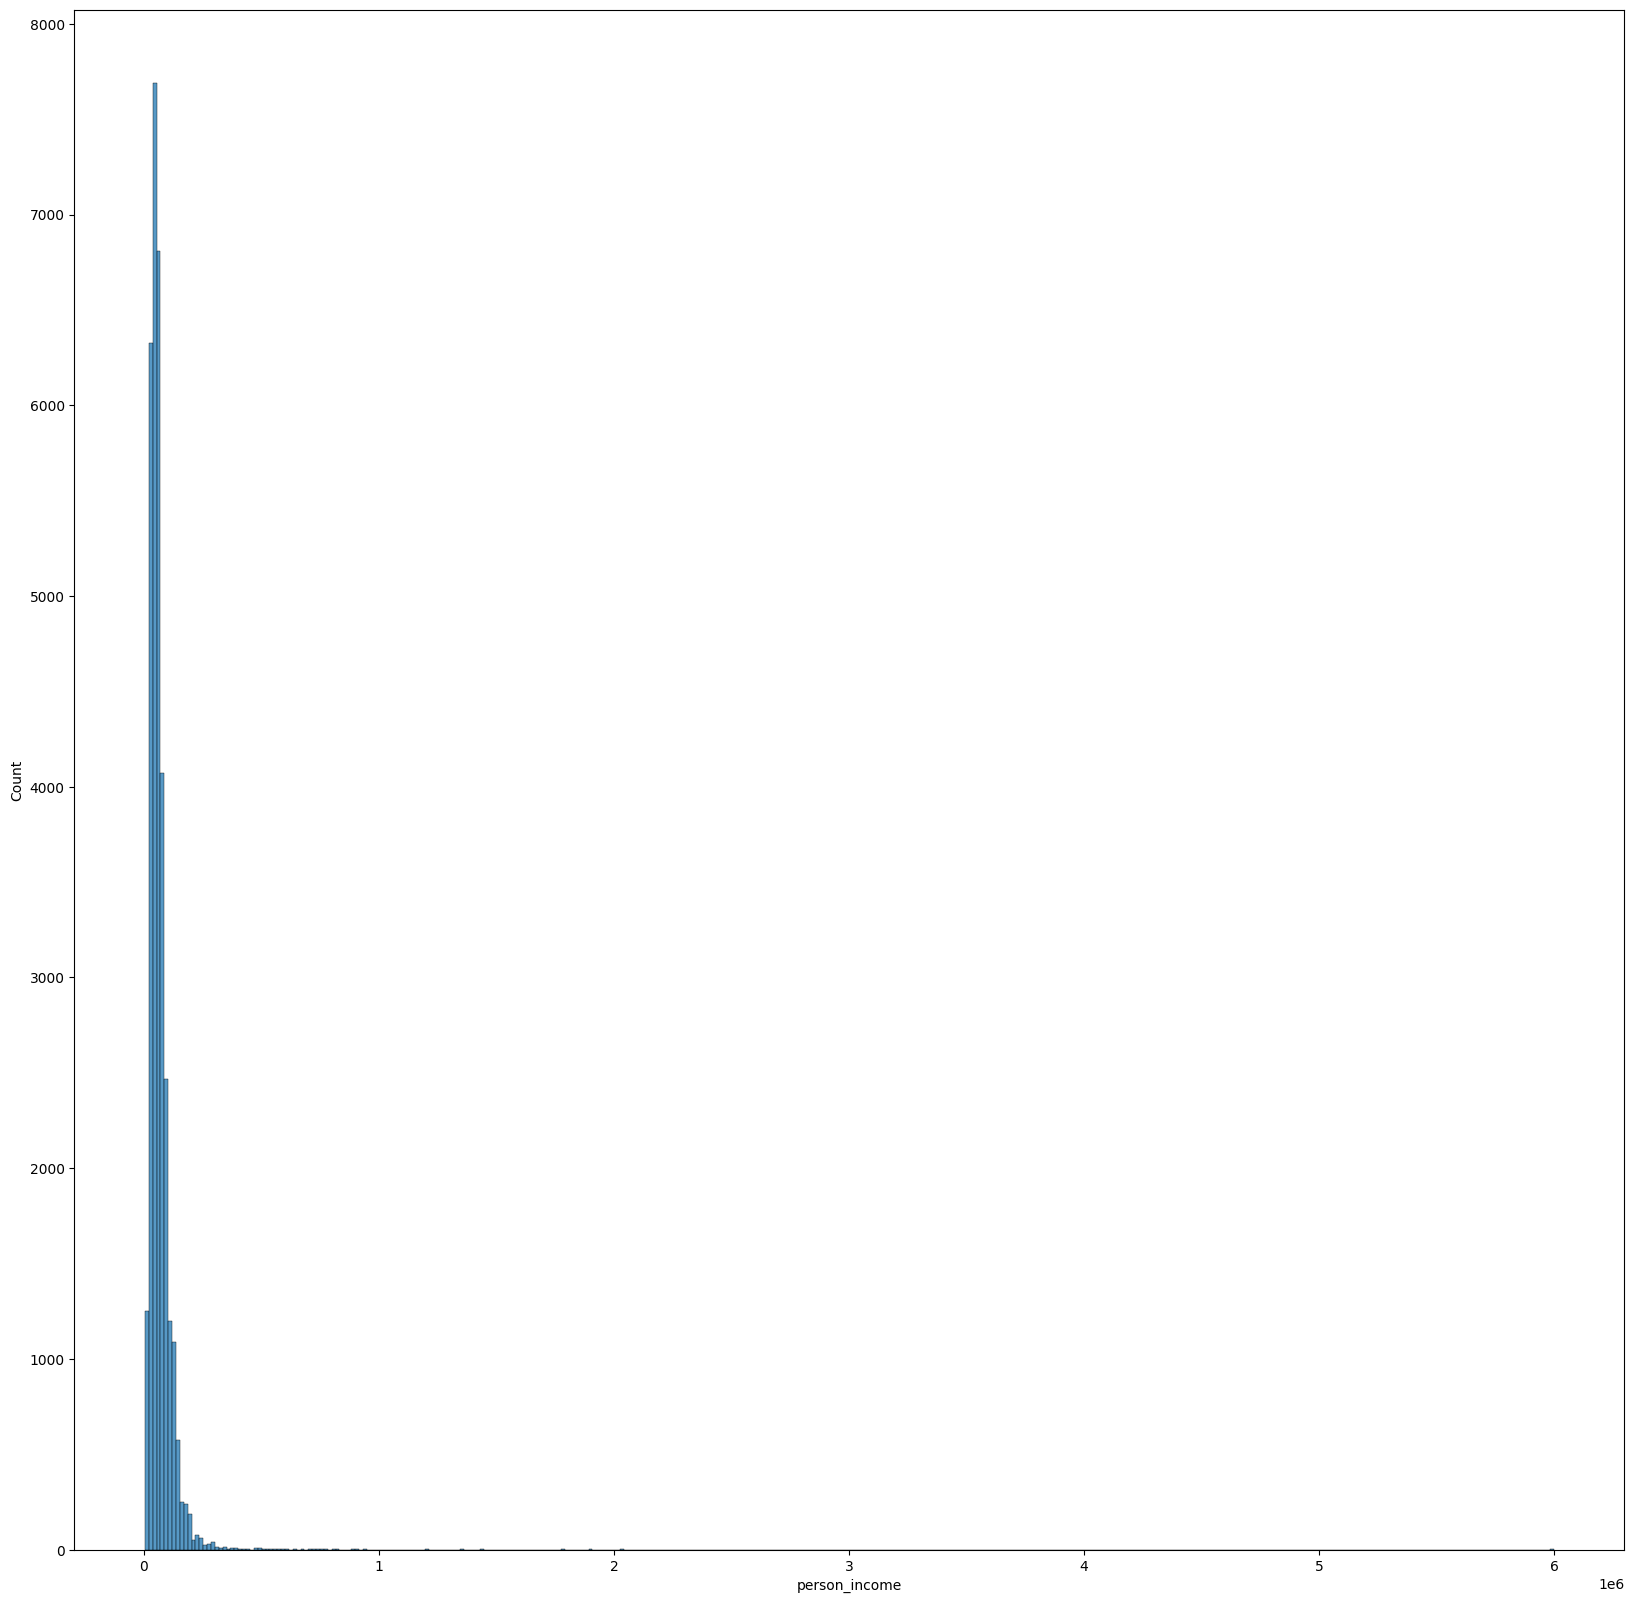

In [298]:
plt.figure(figsize=(20,20))
sns.histplot(data=data,x='person_income')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_income.png',dpi=300,bbox_inches='tight')

In [299]:
Q1 = data['person_income'].quantile(0.25)
Q3 = data['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data['person_income'] = data['person_income'].clip(lower, upper)

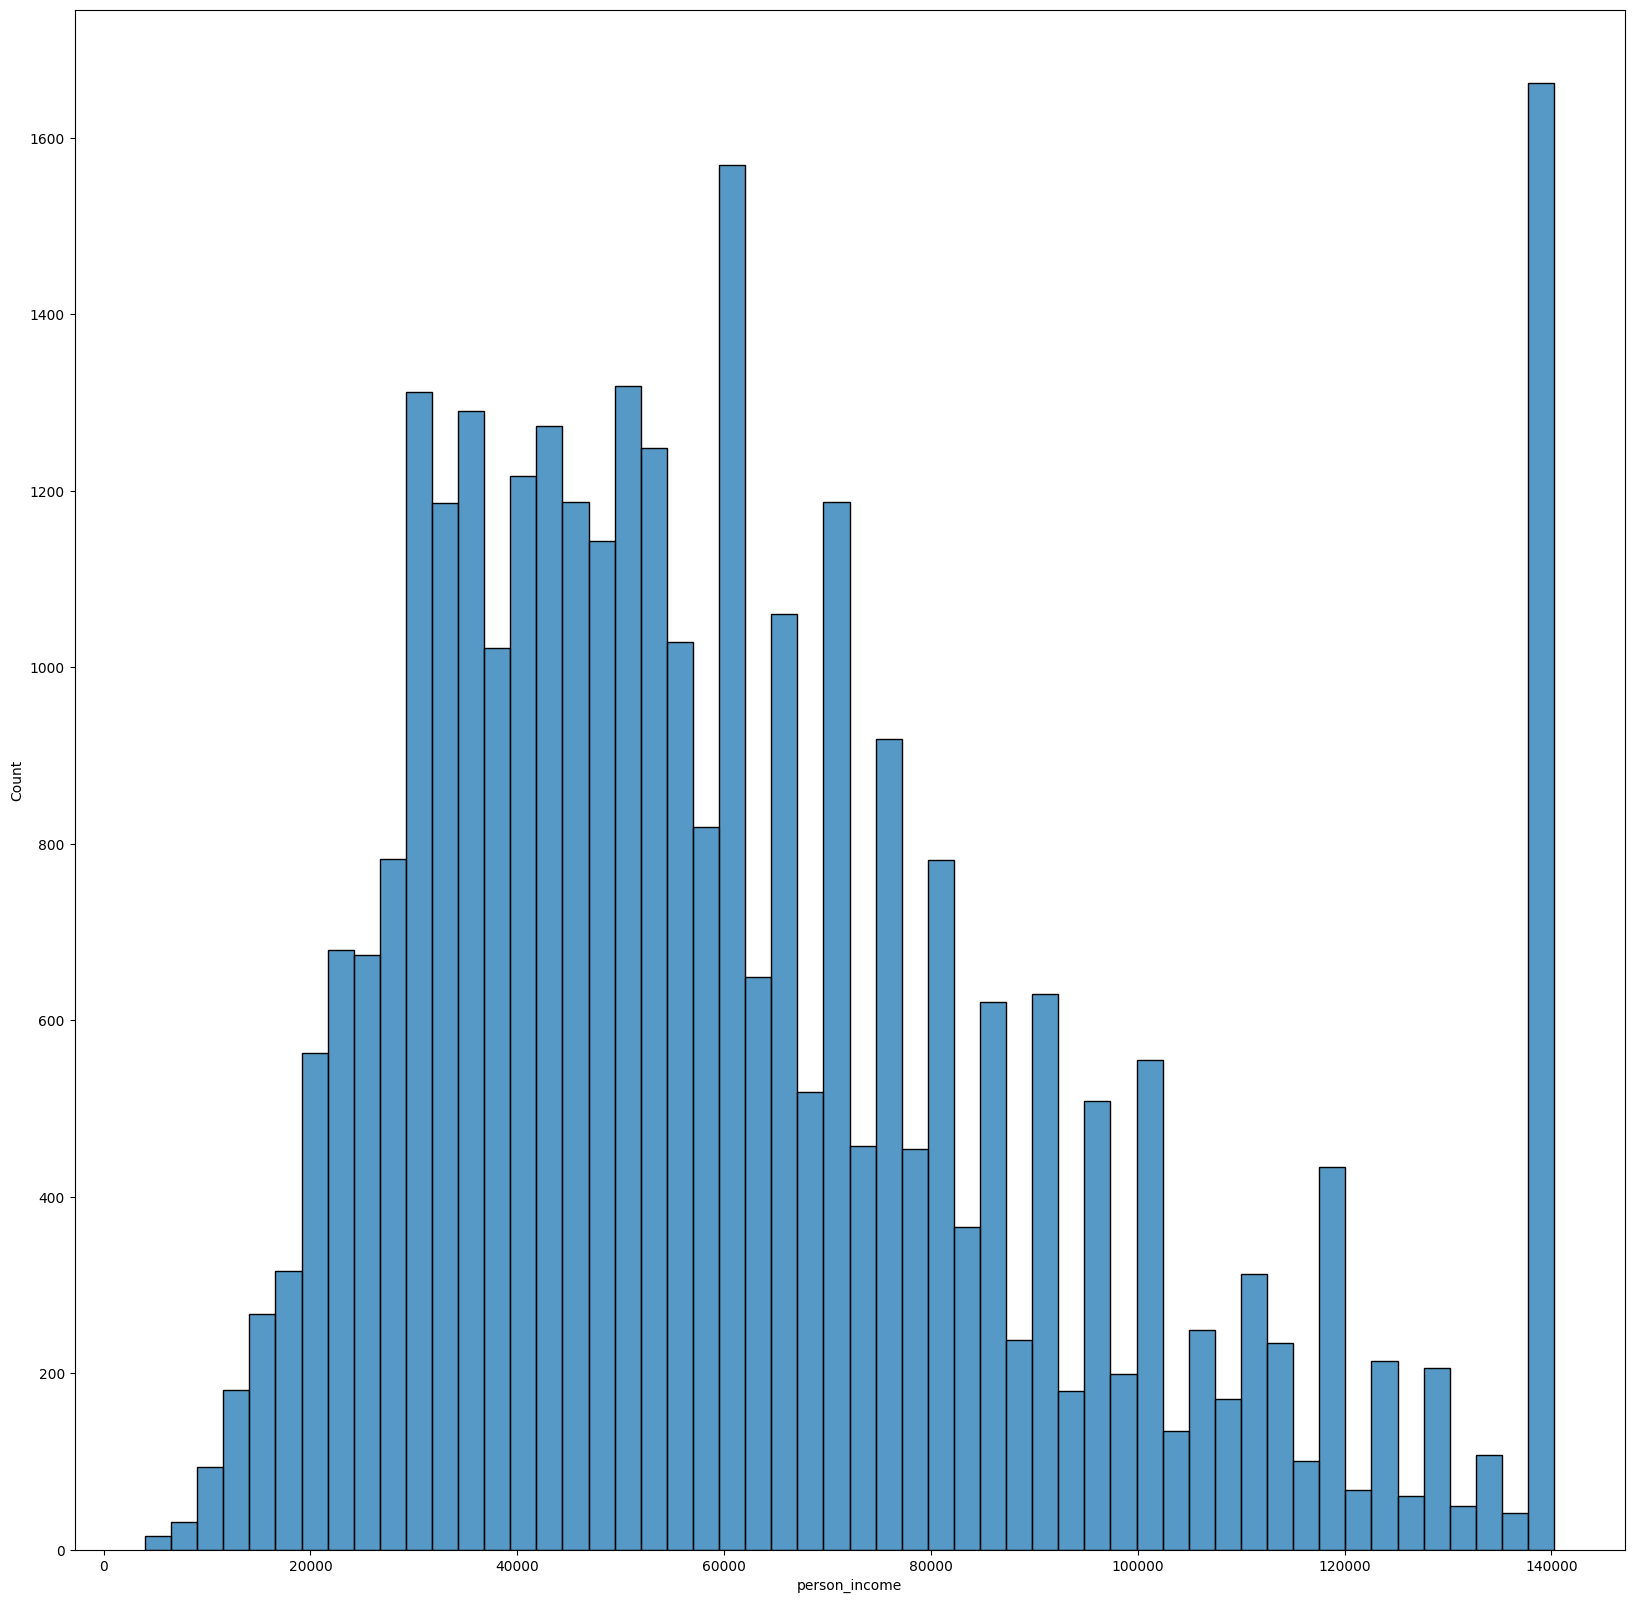

In [300]:
plt.figure(figsize=(20,20))
sns.histplot(data=data,x='person_income')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_income_after.png',dpi=300,bbox_inches='tight')

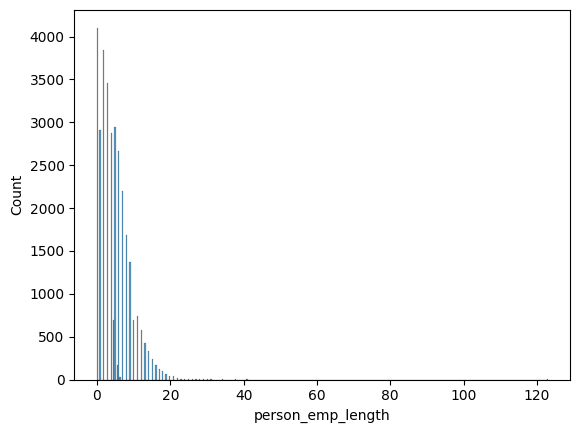

In [301]:
sns.histplot(data=data,x='person_emp_length')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_emp_lenbef.png',dpi=300,bbox_inches='tight')

In [302]:
Q1 = data['person_emp_length'].quantile(0.25)
Q3 = data['person_emp_length'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data['person_emp_length'] = data['person_emp_length'].clip(lower, upper)

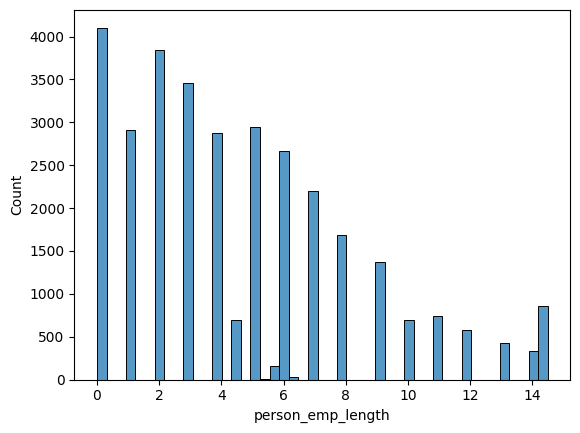

In [303]:
sns.histplot(data=data,x='person_emp_length')

plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-2-Credit-Risk/Images/person_emp_after.png',dpi=300,bbox_inches='tight')

In [304]:
data

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,59000,14.5,3,35000,16.02,1,0.59,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,21.0,9600,5.0,1,1000,11.14,0,0.10,0,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,25.0,9600,1.0,2,5500,12.87,1,0.57,0,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,23.0,65500,4.0,2,35000,15.23,1,0.53,0,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,24.0,54400,8.0,2,35000,14.27,1,0.55,1,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,40.5,53000,1.0,2,5800,13.16,0,0.11,0,30,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32577,40.5,120000,4.0,0,17625,7.49,0,0.15,0,19,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32578,40.5,76000,3.0,1,35000,10.99,1,0.46,0,28,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
32579,40.5,140250,5.0,1,15000,11.48,0,0.10,0,26,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [305]:
# Train Test Split

In [306]:
X = data.drop(['loan_status','age_group'],axis=1)
y = data[['loan_status']]
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,random_state=42,test_size=0.2)

In [307]:
# Scaling

In [308]:
person_age_scaler = StandardScaler()
Xtrain['person_age'] = person_age_scaler.fit_transform(Xtrain[['person_age']])
Xtest['person_age'] = person_age_scaler.transform(Xtest[['person_age']])

In [309]:
# person income 
person_income_scale = StandardScaler()
Xtrain['person_income'] = person_income_scale.fit_transform(Xtrain[['person_income']])
Xtest['person_income'] = person_income_scale.transform(Xtest[['person_income']])


In [310]:
Xtrain

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
32377,2.466069,-0.516847,2.0,2,4800,11.090000,0.10,1,24,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1338,-0.276561,-1.145537,0.0,4,8500,16.450000,0.33,0,3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7047,-0.844002,-0.359675,3.0,2,16000,13.110000,0.31,1,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8225,-1.033149,-0.202377,6.0,0,6000,7.880000,0.11,0,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7178,-0.654855,0.520491,3.0,2,7000,12.540000,0.09,0,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,2.182348,-0.752606,7.0,2,3500,13.980000,0.09,1,17,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,-0.465708,0.206146,5.0,0,8500,6.920000,0.12,0,4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
860,-0.276561,2.445853,1.0,4,20000,17.990000,0.14,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
15795,-0.276561,2.445853,0.0,2,15000,10.998221,0.09,0,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [311]:
loan_amount_scaler =  StandardScaler()
Xtrain['loan_amnt'] = loan_amount_scaler.fit_transform(Xtrain[['loan_amnt']])
Xtest['loan_amnt'] = loan_amount_scaler.transform(Xtest[['loan_amnt']])
Xtrain

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
32377,2.466069,-0.516847,2.0,2,-0.760189,11.090000,0.10,1,24,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1338,-0.276561,-1.145537,0.0,4,-0.174341,16.450000,0.33,0,3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7047,-0.844002,-0.359675,3.0,2,1.013189,13.110000,0.31,1,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8225,-1.033149,-0.202377,6.0,0,-0.570184,7.880000,0.11,0,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7178,-0.654855,0.520491,3.0,2,-0.411847,12.540000,0.09,0,3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,2.182348,-0.752606,7.0,2,-0.966027,13.980000,0.09,1,17,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,-0.465708,0.206146,5.0,0,-0.174341,6.920000,0.12,0,4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
860,-0.276561,2.445853,1.0,4,1.646538,17.990000,0.14,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
15795,-0.276561,2.445853,0.0,2,0.854851,10.998221,0.09,0,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [312]:
Xtrain.info()
Xtest.info()

<class 'pandas.DataFrame'>
Index: 26064 entries, 32377 to 23654
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      26064 non-null  float64
 1   person_income                   26064 non-null  float64
 2   person_emp_length               26064 non-null  float64
 3   loan_grade                      26064 non-null  int64  
 4   loan_amnt                       26064 non-null  float64
 5   loan_int_rate                   26064 non-null  float64
 6   loan_percent_income             26064 non-null  float64
 7   cb_person_default_on_file       26064 non-null  int64  
 8   cb_person_cred_hist_length      26064 non-null  int64  
 9   person_home_ownership_MORTGAGE  26064 non-null  float64
 10  person_home_ownership_OTHER     26064 non-null  float64
 11  person_home_ownership_OWN       26064 non-null  float64
 12  person_home_ownership_RENT      26064 non-nu

In [313]:
# Model 

In [314]:
logistic_regression = LogisticRegression(max_iter=1000)
logistic_regression.fit(Xtrain,ytrain)
# prediction_logistic_regression = logistic_regression.predict(Xtest)

probs = logistic_regression.predict_proba(Xtest)[:,1]

threshold = 0.2
custom_pred = (probs >= threshold).astype(int)

/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [315]:
print(accuracy_score(ytest,custom_pred))
print(precision_score(ytest,custom_pred))
print(recall_score(ytest,custom_pred))
confusion_matrix(ytest,custom_pred)

0.7748964247353076
0.4952667814113597
0.7965397923875432


array([[3899, 1173],
       [ 294, 1151]])

In [316]:
svc_model = SVC()
svc_model.fit(Xtrain,ytrain)
svc_prediction = svc_model.predict(Xtest)

/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [317]:
print(accuracy_score(ytest,svc_prediction))
print(precision_score(ytest,svc_prediction))
print(recall_score(ytest,svc_prediction))
confusion_matrix(ytest,svc_prediction)

0.8506981740064447
0.8268698060941828
0.41314878892733564


array([[4947,  125],
       [ 848,  597]])

In [318]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(Xtrain,ytrain)
knn_prediction = knn_model.predict(Xtest)

/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [319]:
print(accuracy_score(ytest,knn_prediction))
print(precision_score(ytest,knn_prediction))
print(recall_score(ytest,knn_prediction))
confusion_matrix(ytest,knn_prediction)

0.8433328218505447
0.7505910165484634
0.43944636678200694


array([[4861,  211],
       [ 810,  635]])

In [320]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(Xtrain,ytrain)
decision_tree_predict = decision_tree.predict(Xtest)

In [321]:
print(accuracy_score(ytest,knn_prediction))
print(precision_score(ytest,knn_prediction))
print(recall_score(ytest,knn_prediction))
confusion_matrix(ytest,knn_prediction)

0.8433328218505447
0.7505910165484634
0.43944636678200694


array([[4861,  211],
       [ 810,  635]])

In [322]:
random_forest = RandomForestClassifier()
random_forest.fit(Xtrain,ytrain)
random_forest_prediction = random_forest.predict(Xtest)

/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [323]:
print(f'Random Forest accuracy {accuracy_score(ytest,random_forest_prediction)}')
print(f'Random Forest precision {precision_score(ytest,random_forest_prediction)}')
print(f'Random Forest recall {recall_score(ytest,random_forest_prediction)}')
print(f'Random Forest confusion matrix {confusion_matrix(ytest,random_forest_prediction)}')

Random Forest accuracy 0.9330980512505754
Random Forest precision 0.9710550887021475
Random Forest recall 0.7197231833910035
Random Forest confusion matrix [[5041   31]
 [ 405 1040]]
